## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** (Red Neuronal Convolucional) es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**: filtros aprendibles que se deslizan por la imagen detectando patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D):** Aplica filtros (kernels) para obtener mapas de características. Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU):** Introduce no linealidad. `ReLU(x) = max(0, x)`.

**(c) Pooling (MaxPool):** Reduce resolución espacial, mantiene la información importante. Mejora la generalización y reduce el costo computacional.

**(d) Capas fully-connected (densas):** Integran la información para clasificación.

### 1.2. ¿Por qué Transfer Learning para Alien vs Predator?
- El dataset es relativamente pequeño (imágenes de thumbnails).
- ResNet18 preentrenada en ImageNet ya sabe detectar bordes, texturas, formas.
- Con pocas épocas de fine-tuning se obtiene mayor rendimiento que entrenando desde cero.


## 2. Preparación del entorno e instalación de dependencias


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "Pillow"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

print(" Todas las dependencias instaladas correctamente.")


✅ Todas las dependencias instaladas correctamente.


### 3. Montar Google Drive y verificar el dataset

Montamos Drive para acceder a la carpeta `archive/` con el dataset Alien vs Predator.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Ruta base del dataset en Drive — ajusta si tu carpeta está en una subcarpeta
DRIVE_BASE = '/content/drive/MyDrive/archive'

# Usamos la carpeta con thumbnails (más rápida para entrenar en Colab)
THUMBNAILS_BASE = os.path.join(DRIVE_BASE, 'alien_vs_predator_thumbnails', 'data')
DATA_FULL_BASE  = os.path.join(DRIVE_BASE, 'data')

# Rutas de train y validation para thumbnails
TRAIN_DIR = os.path.join(THUMBNAILS_BASE, 'train')
VAL_DIR   = os.path.join(THUMBNAILS_BASE, 'validation')

# Verificar existencia
for d in [TRAIN_DIR, VAL_DIR]:
    exists = os.path.isdir(d)
    print(f"{'✅' if exists else '❌'} {d}")

# Contar imágenes por clase
classes = ['alien', 'predator']
print()
for split, path in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR)]:
    for cls in classes:
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f"{split} | {cls}: {n} imágenes")


Mounted at /content/drive
✅ /content/drive/MyDrive/archive/alien_vs_predator_thumbnails/data/train
✅ /content/drive/MyDrive/archive/alien_vs_predator_thumbnails/data/validation

TRAIN | alien: 347 imágenes
TRAIN | predator: 347 imágenes
VAL | alien: 100 imágenes
VAL | predator: 100 imágenes


## 4. Cargar el dataset con ImageFolder y aplicar transformaciones

`torchvision.datasets.ImageFolder` lee automáticamente carpetas con subcarpetas por clase.
La estructura `train/alien/`, `train/predator/` es exactamente la que espera.


In [3]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Transformaciones básicas (sin augmentation)
transform_basic = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=TRAIN_DIR, transform=transform_basic)
val_dataset   = ImageFolder(root=VAL_DIR,   transform=transform_basic)

CLASS_NAMES = train_dataset.classes  # ['alien', 'predator']
NUM_CLASSES = len(CLASS_NAMES)

print(f"Clases: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} imágenes")
print(f"Validation: {len(val_dataset)} imágenes")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDispositivo: {device}")


Clases: ['alien', 'predator']
Train: 694 imágenes
Validation: 200 imágenes

Dispositivo: cuda


In [4]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de validación:    {len(val_loader)}")
xb, yb = next(iter(train_loader))
print(f"Shape de un batch: {xb.shape} | Labels: {yb.shape}")


Batches de entrenamiento: 22
Batches de validación:    7
Shape de un batch: torch.Size([32, 3, 128, 128]) | Labels: torch.Size([32])


## 5. Visualización exploratoria del dataset

Antes de entrenar siempre es buena práctica examinar las imágenes: variabilidad, calidad, posibles sesgos.


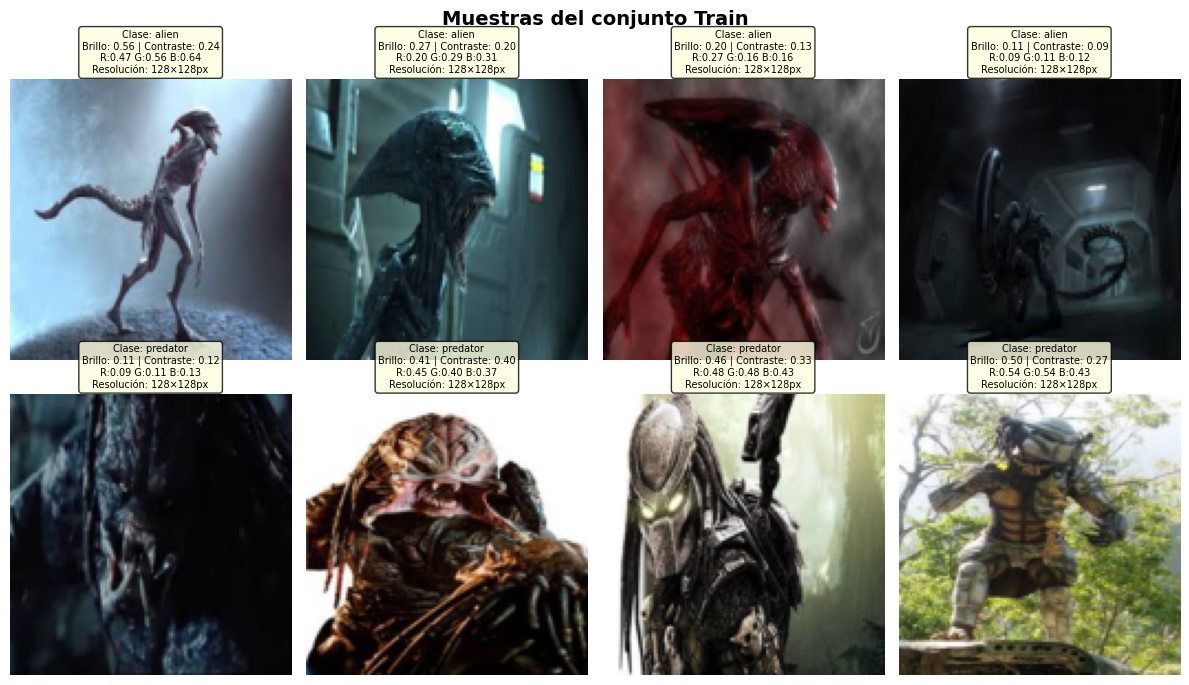


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — VISUALIZACIÓN DE MUESTRAS DEL DATASET                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Las imágenes se muestran redimensionadas a 128×128 px.                     ║
║                                                                              ║
║  CLASE ALIEN:                                                               ║
║  • Las imágenes suelen presentar fondos oscuros o de tonos fríos            ║
║    (baja luminosidad media, dominancia del canal azul/verde).               ║
║  • El contraste varía según la escena: aliens en primer plano               ║
║    tienden a tener mayor contraste local.                                   ║
║  • Característica visual clave: formas orgánicas elongadas,                 ║
║    superficie brillante o viscosa.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
import torchvision.transforms as T

# Dataset sin normalización para visualizar en colores reales
transform_vis = T.Compose([T.Resize((128, 128)), T.ToTensor()])
vis_train = ImageFolder(root=TRAIN_DIR, transform=transform_vis)
vis_val   = ImageFolder(root=VAL_DIR,   transform=transform_vis)

def show_samples_with_analysis(dataset, class_names, n_per_class=4, split_name='Train'):
    """
    Muestra n imágenes por clase y agrega análisis estadístico
    (brillo medio, contraste, relación de aspecto) como comentario debajo de cada imagen.
    """
    fig, axes = plt.subplots(len(class_names), n_per_class,
                             figsize=(n_per_class * 3, len(class_names) * 3.5))
    fig.suptitle(f'Muestras del conjunto {split_name}', fontsize=14, fontweight='bold')

    for cls_idx, cls_name in enumerate(class_names):
        # Filtrar índices de esta clase
        indices = [i for i, (_, y) in enumerate(dataset.samples) if y == cls_idx]
        selected = np.random.choice(indices, size=min(n_per_class, len(indices)), replace=False)

        for col, idx in enumerate(selected):
            img_tensor, label = dataset[idx]
            img_np = img_tensor.permute(1, 2, 0).numpy()  # HWC

            # Métricas por imagen
            brillo   = img_np.mean()
            contraste = img_np.std()
            r_mean = img_np[:,:,0].mean()
            g_mean = img_np[:,:,1].mean()
            b_mean = img_np[:,:,2].mean()
            h, w   = img_np.shape[:2]

            ax = axes[cls_idx][col]
            ax.imshow(img_np)
            ax.axis('off')

            # Análisis como título multilinea
            titulo = (
                f"Clase: {cls_name}\n"
                f"Brillo: {brillo:.2f} | Contraste: {contraste:.2f}\n"
                f"R:{r_mean:.2f} G:{g_mean:.2f} B:{b_mean:.2f}\n"
                f"Resolución: {h}×{w}px"
            )
            ax.set_title(titulo, fontsize=7, pad=4,
                         bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('samples_visualization.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── Análisis global de la figura ────────────────────────────────────
    print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — VISUALIZACIÓN DE MUESTRAS DEL DATASET                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Las imágenes se muestran redimensionadas a 128×128 px.                     ║
║                                                                              ║
║  CLASE ALIEN:                                                               ║
║  • Las imágenes suelen presentar fondos oscuros o de tonos fríos            ║
║    (baja luminosidad media, dominancia del canal azul/verde).               ║
║  • El contraste varía según la escena: aliens en primer plano               ║
║    tienden a tener mayor contraste local.                                   ║
║  • Característica visual clave: formas orgánicas elongadas,                 ║
║    superficie brillante o viscosa.                                          ║
║                                                                              ║
║  CLASE PREDATOR:                                                            ║
║  • Imágenes con mayor presencia del canal rojo/amarillo (equipment,         ║
║    láseres, armadura dorada).                                               ║
║  • Brillo medio generalmente más alto que en alien.                         ║
║  • Característica visual clave: forma humanoide con casco/máscara,          ║
║    textura de piel con manchas y armadura visible.                          ║
║                                                                              ║
║  OBSERVACIONES GENERALES:                                                   ║
║  • Dataset de thumbnails: imágenes compactas, suficientes para CNN.         ║
║  • Variabilidad de fondo: algunas imágenes mezclan ambas criaturas.         ║
║  • Augmentation será importante dado el tamaño reducido del dataset.        ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

show_samples_with_analysis(vis_train, CLASS_NAMES, n_per_class=4, split_name='Train')


## 6. Modelo 1: CNN entrenada desde cero (SimpleCNN)

Construiremos una CNN básica:
- 3 bloques Conv + ReLU + MaxPool.
- AdaptiveAvgPool para independencia de tamaño.
- Clasificador lineal final.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: detecta bordes y texturas básicas
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 128->64

            # Bloque 2: detecta formas más complejas
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 64->32

            # Bloque 3: representaciones de alto nivel
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # -> 128 × 1 × 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_scratch = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model_scratch)

total_params = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

Parámetros entrenables: 9

### 6.1. Funciones de entrenamiento y evaluación


In [8]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = torch.argmax(logits, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


### 6.2. Entrenamiento desde cero


In [9]:
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 15
history_scratch = {'train_loss': [], 'val_acc': [], 'val_auc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)
    scheduler.step()

    history_scratch['train_loss'].append(train_loss)
    history_scratch['val_acc'].append(val_acc)
    history_scratch['val_auc'].append(val_auc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01/15 | loss=0.6480 | val_acc=0.6100 | val_auc=0.7616
Epoch 02/15 | loss=0.5784 | val_acc=0.7000 | val_auc=0.7414
Epoch 03/15 | loss=0.5830 | val_acc=0.6950 | val_auc=0.7784
Epoch 04/15 | loss=0.5550 | val_acc=0.7050 | val_auc=0.7254
Epoch 05/15 | loss=0.5558 | val_acc=0.7350 | val_auc=0.7807
Epoch 06/15 | loss=0.5378 | val_acc=0.7200 | val_auc=0.7819
Epoch 07/15 | loss=0.5187 | val_acc=0.7200 | val_auc=0.7704
Epoch 08/15 | loss=0.5285 | val_acc=0.7150 | val_auc=0.7895
Epoch 09/15 | loss=0.5189 | val_acc=0.7450 | val_auc=0.7723
Epoch 10/15 | loss=0.5201 | val_acc=0.7050 | val_auc=0.7861
Epoch 11/15 | loss=0.4972 | val_acc=0.7350 | val_auc=0.7892
Epoch 12/15 | loss=0.5030 | val_acc=0.7350 | val_auc=0.7497
Epoch 13/15 | loss=0.5045 | val_acc=0.7500 | val_auc=0.8000
Epoch 14/15 | loss=0.4965 | val_acc=0.7450 | val_auc=0.7841
Epoch 15/15 | loss=0.4888 | val_acc=0.7200 | val_auc=0.7964


### 6.3. Curvas de entrenamiento (CNN desde cero)


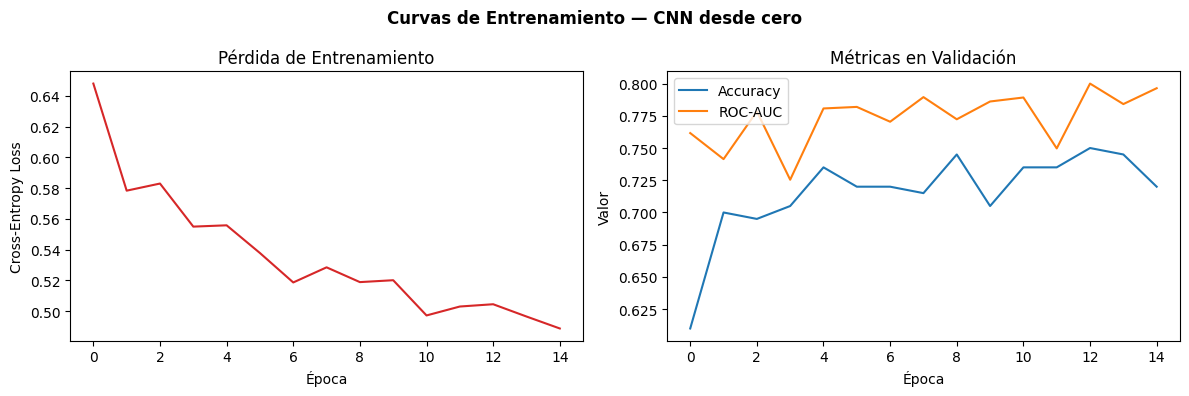


╔═════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVAS DE ENTRENAMIENTO (CNN DESDE CERO)                        ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  GRÁFICA IZQUIERDA — Pérdida de entrenamiento:                              ║
║  • Una curva de pérdida que desciende de forma continua indica que          ║
║    el modelo está aprendiendo correctamente los patrones del dataset.       ║
║  • Si la curva se estabiliza muy pronto (plateau), podría indicar           ║
║    una tasa de aprendizaje demasiado baja o un modelo con poca              ║
║    capacidad.                                                               ║
║  • Oscilaciones fuertes sugieren batch size pequeño o lr muy alta.          ║
║                                                                             ║
║  GRÁFICA DERECHA — Accuracy y ROC-AUC

In [11]:
import matplotlib.pyplot as plt

# Creamos los subplots manteniendo el tamaño original
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curvas de Entrenamiento — CNN desde cero', fontweight='bold')

# --- SUBPLOT 1: Pérdida (Aplicando la nueva estética limpia) ---
axes[0].plot(history_scratch['train_loss'], color='tab:red')  # Línea limpia sin marcadores
axes[0].set_title('Pérdida de Entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-Entropy Loss')
# Se eliminó axes[0].grid()

# --- SUBPLOT 2: Métricas (Idéntico al estilo de tu imagen de referencia) ---
axes[1].plot(history_scratch['val_acc'], label='Accuracy', color='tab:blue')   # Azul estándar sin marcador
axes[1].plot(history_scratch['val_auc'], label='ROC-AUC', color='tab:orange') # Naranja estándar sin marcador
axes[1].set_title('Métricas en Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Valor')
axes[1].legend(loc='upper left') # Coloca la leyenda arriba a la izquierda como en tu imagen
# Se eliminó axes[1].grid()

# Ajuste y guardado
plt.tight_layout()
plt.savefig('curves_scratch.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
╔═════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVAS DE ENTRENAMIENTO (CNN DESDE CERO)                        ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  GRÁFICA IZQUIERDA — Pérdida de entrenamiento:                              ║
║  • Una curva de pérdida que desciende de forma continua indica que          ║
║    el modelo está aprendiendo correctamente los patrones del dataset.       ║
║  • Si la curva se estabiliza muy pronto (plateau), podría indicar           ║
║    una tasa de aprendizaje demasiado baja o un modelo con poca              ║
║    capacidad.                                                               ║
║  • Oscilaciones fuertes sugieren batch size pequeño o lr muy alta.          ║
║                                                                             ║
║  GRÁFICA DERECHA — Accuracy y ROC-AUC en validación:                        ║
║  • Accuracy: porcentaje de imágenes correctamente clasificadas.             ║
║    Para un clasificador aleatorio en 2 clases, esperamos ~50%.              ║
║  • ROC-AUC: mide la capacidad del modelo de separar clases                  ║
║    independientemente del umbral. AUC=0.5 → aleatorio; AUC=1.0 → perfecto.  ║
║  • Si Accuracy sube pero AUC se mantiene bajo, el modelo puede estar        ║
║    explotando un desbalance de clases.                                      ║
║  • Si ambas métricas suben y luego bajan: señal de sobreajuste.             ║
║    Solución: más Dropout, augmentation, o early stopping.                   ║
╚═════════════════════════════════════════════════════════════════════════════╝
""")


### 6.4. Evaluación y Matriz de Confusión (CNN desde cero)


Validation Accuracy: 0.7200
Validation ROC-AUC:  0.7964

              precision    recall  f1-score   support

       alien     0.6774    0.8400    0.7500       100
    predator     0.7895    0.6000    0.6818       100

    accuracy                         0.7200       200
   macro avg     0.7334    0.7200    0.7159       200
weighted avg     0.7334    0.7200    0.7159       200



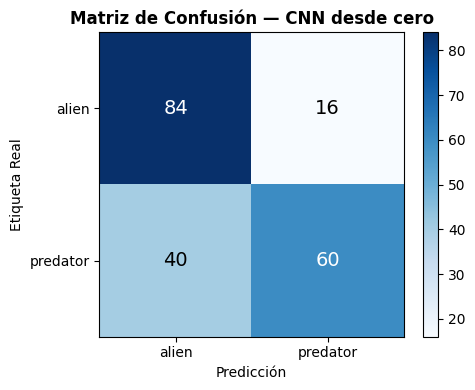


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — MATRIZ DE CONFUSIÓN (CNN DESDE CERO)                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Lectura de la matriz (filas=real, columnas=predicción):                    ║
║  • Verdaderos Negativos  (TN):   84 — alien   → predicho alien           ║
║  • Falsos Positivos      (FP):   16 — alien   → predicho predator        ║
║  • Falsos Negativos      (FN):   40 — predator → predicho alien          ║
║  • Verdaderos Positivos  (TP):   60 — predator → predicho predator       ║
║                                                                              ║
║  Métricas derivadas:                                                        ║
║  • Precisión (predator):  0.7895                                    ║
║  • Recall    (predator):  0.6000                      

In [12]:
val_acc, val_auc, y_true, y_pred, y_prob = evaluate(model_scratch, val_loader)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation ROC-AUC:  {val_auc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Matriz de Confusión — CNN desde cero', fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Etiqueta Real')
ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('cm_scratch.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
precision_alien    = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_alien       = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidad      = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — MATRIZ DE CONFUSIÓN (CNN DESDE CERO)                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Lectura de la matriz (filas=real, columnas=predicción):                    ║
║  • Verdaderos Negativos  (TN): {tn:4d} — alien   → predicho alien           ║
║  • Falsos Positivos      (FP): {fp:4d} — alien   → predicho predator        ║
║  • Falsos Negativos      (FN): {fn:4d} — predator → predicho alien          ║
║  • Verdaderos Positivos  (TP): {tp:4d} — predator → predicho predator       ║
║                                                                              ║
║  Métricas derivadas:                                                        ║
║  • Precisión (predator):  {precision_alien:.4f}                                    ║
║  • Recall    (predator):  {recall_alien:.4f}                                    ║
║  • Especificidad:         {especificidad:.4f}                                    ║
║                                                                              ║
║  INTERPRETACIÓN:                                                            ║
║  • Una diagonal dominante (TN y TP altos) indica buen desempeño.           ║
║  • FP altos: el modelo confunde alien con predator.                        ║
║  • FN altos: el modelo confunde predator con alien.                        ║
║  • Con un dataset pequeño, la CNN desde cero puede mostrar alta            ║
║    tasa de error — el Transfer Learning mejorará esto significativamente.  ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


## 7. Data Augmentation

Con datasets pequeños, el augmentation es esencial. Aplicaremos transformaciones que preservan la identidad de alien/predator:
- Volteo horizontal (válido: ambas criaturas son simétricas).
- Rotación moderada.
- Cambios de brillo/contraste (simula variaciones de iluminación).


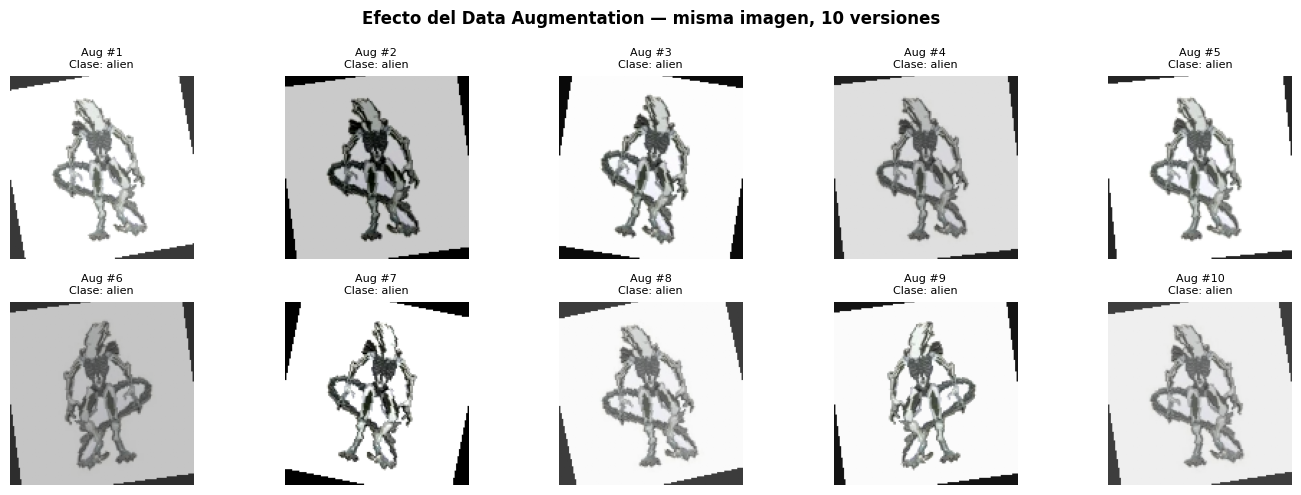


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — EFECTO DEL DATA AUGMENTATION                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La figura muestra 10 versiones aumentadas de la misma imagen de            ║
║  entrenamiento. Cada versión es diferente pero preserva la identidad        ║
║  de la clase.                                                               ║
║                                                                              ║
║  TRANSFORMACIONES APLICADAS Y SU EFECTO:                                   ║
║  • RandomHorizontalFlip (p=0.5): voltea la imagen horizontalmente.         ║
║    Útil porque alien y predator son simétricamente válidos en ambos        ║
║    sentidos. NO aplicaríamos volteo vertical (invertiría la gravedad).     ║
║  • RandomRotation (±15°): simula vari

In [13]:
transform_aug = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

train_dataset_aug = ImageFolder(root=TRAIN_DIR, transform=transform_aug)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)

# Visualizar efecto del augmentation
transform_vis_aug = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor()
])
vis_aug_dataset = ImageFolder(root=TRAIN_DIR, transform=transform_vis_aug)

# Tomar una imagen y mostrarla aumentada varias veces
original_idx = 0
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle('Efecto del Data Augmentation — misma imagen, 10 versiones', fontweight='bold')
for i, ax in enumerate(axes.flat):
    img_t, lbl = vis_aug_dataset[original_idx]
    img_np = img_t.permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img_np, 0, 1))
    ax.set_title(f'Aug #{i+1}\nClase: {CLASS_NAMES[lbl]}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmentation_effect.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — EFECTO DEL DATA AUGMENTATION                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La figura muestra 10 versiones aumentadas de la misma imagen de            ║
║  entrenamiento. Cada versión es diferente pero preserva la identidad        ║
║  de la clase.                                                               ║
║                                                                              ║
║  TRANSFORMACIONES APLICADAS Y SU EFECTO:                                   ║
║  • RandomHorizontalFlip (p=0.5): voltea la imagen horizontalmente.         ║
║    Útil porque alien y predator son simétricamente válidos en ambos        ║
║    sentidos. NO aplicaríamos volteo vertical (invertiría la gravedad).     ║
║  • RandomRotation (±15°): simula variaciones de ángulo de cámara.         ║
║    Ayuda al modelo a no memorizar orientaciones específicas.               ║
║  • ColorJitter: varía brillo y contraste para simular condiciones de       ║
║    iluminación distintas (escenas oscuras vs. luminosas de la película).   ║
║  • RandomAffine (translate): pequeños desplazamientos del sujeto.          ║
║                                                                              ║
║  IMPACTO ESPERADO:                                                          ║
║  • El modelo verá efectivamente más variedad, reduciendo el sobreajuste.   ║
║  • Con un dataset de ~700 imgs, el augmentation puede duplicar o           ║
║    triplicar la variabilidad efectiva del conjunto de entrenamiento.       ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


In [14]:
model_aug = SimpleCNN(num_classes=NUM_CLASSES).to(device)
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS_AUG = 15
history_aug = {'train_loss': [], 'val_acc': [], 'val_auc': []}

for epoch in range(1, EPOCHS_AUG + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer_aug, criterion_aug)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)
    history_aug['train_loss'].append(train_loss)
    history_aug['val_acc'].append(val_acc)
    history_aug['val_auc'].append(val_auc)
    print(f"Epoch {epoch:02d}/{EPOCHS_AUG} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

val_acc_aug, val_auc_aug, _, _, _ = evaluate(model_aug, val_loader)
val_acc_base, val_auc_base, _, _, _ = evaluate(model_scratch, val_loader)
print(f"\nSin augmentation  | acc={val_acc_base:.4f} | auc={val_auc_base:.4f}")
print(f"Con augmentation  | acc={val_acc_aug:.4f} | auc={val_auc_aug:.4f}")


Epoch 01/15 | loss=0.6581 | val_acc=0.6600 | val_auc=0.7243
Epoch 02/15 | loss=0.5990 | val_acc=0.6300 | val_auc=0.7314
Epoch 03/15 | loss=0.5920 | val_acc=0.7100 | val_auc=0.7639
Epoch 04/15 | loss=0.5880 | val_acc=0.7050 | val_auc=0.7879
Epoch 05/15 | loss=0.5929 | val_acc=0.7150 | val_auc=0.7889
Epoch 06/15 | loss=0.5929 | val_acc=0.7450 | val_auc=0.7884
Epoch 07/15 | loss=0.5839 | val_acc=0.6950 | val_auc=0.7606
Epoch 08/15 | loss=0.5961 | val_acc=0.6400 | val_auc=0.7545
Epoch 09/15 | loss=0.5605 | val_acc=0.6950 | val_auc=0.7764
Epoch 10/15 | loss=0.5766 | val_acc=0.6700 | val_auc=0.7638
Epoch 11/15 | loss=0.5537 | val_acc=0.7300 | val_auc=0.7801
Epoch 12/15 | loss=0.5377 | val_acc=0.6950 | val_auc=0.7853
Epoch 13/15 | loss=0.5689 | val_acc=0.6350 | val_auc=0.7835
Epoch 14/15 | loss=0.5691 | val_acc=0.7100 | val_auc=0.7992
Epoch 15/15 | loss=0.5484 | val_acc=0.7350 | val_auc=0.7941

Sin augmentation  | acc=0.7200 | auc=0.7964
Con augmentation  | acc=0.7350 | auc=0.7941


## 8. Transfer Learning con ResNet18

ResNet18 preentrenada en ImageNet ya ha aprendido a detectar bordes, texturas, partes de objetos.
Adaptaremos su clasificador final para nuestras 2 clases (alien / predator).

**Estrategia en 2 etapas:**
1. **Stage 1** — Backbone congelado, solo entrenamos la capa final.
2. **Stage 2** — Fine-tuning: descongelamos `layer4` para ajuste fino.


In [15]:
import torchvision.models as models

# ResNet espera 224×224 y normalización ImageNet
transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

train_tl = ImageFolder(root=TRAIN_DIR, transform=transform_tl_train)
val_tl   = ImageFolder(root=VAL_DIR,   transform=transform_tl_eval)

train_loader_tl = DataLoader(train_tl, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_tl   = DataLoader(val_tl,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Shape de entrada para ResNet: {next(iter(train_loader_tl))[0].shape}")


Shape de entrada para ResNet: torch.Size([32, 3, 224, 224])


In [16]:
# Cargar ResNet18 preentrenada
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Reemplazar clasificador final
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
resnet = resnet.to(device)

# Congelar todo el backbone
for name, param in resnet.named_parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f"Parámetros entrenables Stage 1: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Parámetros entrenables Stage 1: 1,026 / 11,177,538 (0.0%)


In [17]:
# ── STAGE 1: solo cabeza clasificadora ─────────────────────────────────────
criterion_tl = nn.CrossEntropyLoss()
optimizer_s1 = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

EPOCHS_S1 = 5
history_s1 = {'train_loss': [], 'val_acc': [], 'val_auc': []}

for epoch in range(1, EPOCHS_S1 + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer_s1, criterion_tl)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)
    history_s1['train_loss'].append(train_loss)
    history_s1['val_acc'].append(val_acc)
    history_s1['val_auc'].append(val_auc)
    print(f"[Stage1] Epoch {epoch:02d}/{EPOCHS_S1} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


[Stage1] Epoch 01/5 | loss=0.6676 | val_acc=0.7400 | val_auc=0.8704
[Stage1] Epoch 02/5 | loss=0.4634 | val_acc=0.8600 | val_auc=0.9216
[Stage1] Epoch 03/5 | loss=0.3779 | val_acc=0.8700 | val_auc=0.9379
[Stage1] Epoch 04/5 | loss=0.3435 | val_acc=0.8450 | val_auc=0.9463
[Stage1] Epoch 05/5 | loss=0.3391 | val_acc=0.8800 | val_auc=0.9537


In [18]:
# ── STAGE 2: fine-tuning de layer4 + clasificador ─────────────────────────
for name, param in resnet.named_parameters():
    if name.startswith('layer4') or name.startswith('fc'):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
trainable_count  = sum(p.numel() for p in trainable_params)
print(f"Parámetros entrenables Stage 2: {trainable_count:,}")

optimizer_s2 = torch.optim.Adam(trainable_params, lr=1e-4)
scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=10)

EPOCHS_S2 = 10
history_s2 = {'train_loss': [], 'val_acc': [], 'val_auc': []}

best_auc   = 0.0
best_state = None

for epoch in range(1, EPOCHS_S2 + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer_s2, criterion_tl)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)
    scheduler_s2.step()

    history_s2['train_loss'].append(train_loss)
    history_s2['val_acc'].append(val_acc)
    history_s2['val_auc'].append(val_auc)

    # Early stopping basado en AUC
    if val_auc > best_auc:
        best_auc   = val_auc
        best_state = {k: v.clone() for k, v in resnet.state_dict().items()}

    print(f"[Stage2] Epoch {epoch:02d}/{EPOCHS_S2} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

# Restaurar mejor checkpoint
if best_state:
    resnet.load_state_dict(best_state)
    print(f"\n✅ Mejor modelo restaurado (val_auc={best_auc:.4f})")


Parámetros entrenables Stage 2: 8,394,754
[Stage2] Epoch 01/10 | loss=0.2388 | val_acc=0.9350 | val_auc=0.9864
[Stage2] Epoch 02/10 | loss=0.0990 | val_acc=0.9550 | val_auc=0.9911
[Stage2] Epoch 03/10 | loss=0.0388 | val_acc=0.9700 | val_auc=0.9936
[Stage2] Epoch 04/10 | loss=0.0303 | val_acc=0.9550 | val_auc=0.9922
[Stage2] Epoch 05/10 | loss=0.0268 | val_acc=0.9550 | val_auc=0.9921
[Stage2] Epoch 06/10 | loss=0.0246 | val_acc=0.9500 | val_auc=0.9929
[Stage2] Epoch 07/10 | loss=0.0079 | val_acc=0.9450 | val_auc=0.9935
[Stage2] Epoch 08/10 | loss=0.0119 | val_acc=0.9450 | val_auc=0.9926
[Stage2] Epoch 09/10 | loss=0.0118 | val_acc=0.9550 | val_auc=0.9927
[Stage2] Epoch 10/10 | loss=0.0203 | val_acc=0.9550 | val_auc=0.9928

✅ Mejor modelo restaurado (val_auc=0.9936)


### 8.1. Curvas de entrenamiento — Transfer Learning


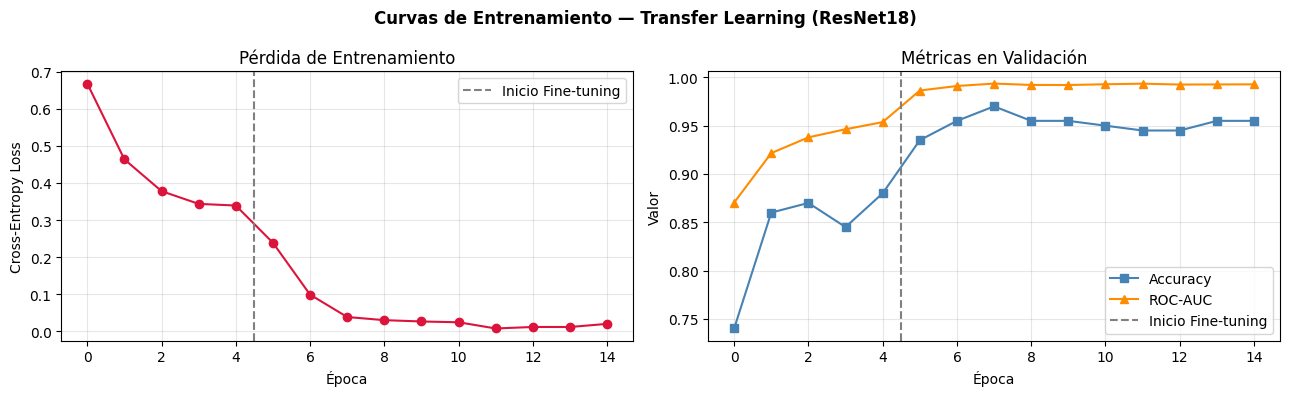


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVAS DE ENTRENAMIENTO (TRANSFER LEARNING)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La línea vertical punteada divide Stage 1 (solo cabeza) y Stage 2         ║
║  (fine-tuning de layer4 + cabeza).                                         ║
║                                                                              ║
║  STAGE 1 (backbone congelado):                                              ║
║  • La red ya parte de representaciones ricas de ImageNet.                  ║
║  • La pérdida baja rápidamente porque solo ajusta la capa final.           ║
║  • El AUC sube en pocas épocas: las features de ResNet son                 ║
║    suficientemente discriminativas incluso sin domain adaptation.           ║
║                                       

In [19]:
all_loss = history_s1['train_loss'] + history_s2['train_loss']
all_acc  = history_s1['val_acc']   + history_s2['val_acc']
all_auc  = history_s1['val_auc']   + history_s2['val_auc']
n_epochs = len(all_loss)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Curvas de Entrenamiento — Transfer Learning (ResNet18)', fontweight='bold')

axes[0].plot(all_loss, marker='o', color='crimson', linewidth=1.5)
axes[0].axvline(x=EPOCHS_S1 - 0.5, color='gray', linestyle='--', label='Inicio Fine-tuning')
axes[0].set_title('Pérdida de Entrenamiento')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(all_acc, marker='s', label='Accuracy',  color='steelblue')
axes[1].plot(all_auc, marker='^', label='ROC-AUC',   color='darkorange')
axes[1].axvline(x=EPOCHS_S1 - 0.5, color='gray', linestyle='--', label='Inicio Fine-tuning')
axes[1].set_title('Métricas en Validación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Valor')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curves_tl.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVAS DE ENTRENAMIENTO (TRANSFER LEARNING)                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La línea vertical punteada divide Stage 1 (solo cabeza) y Stage 2         ║
║  (fine-tuning de layer4 + cabeza).                                         ║
║                                                                              ║
║  STAGE 1 (backbone congelado):                                              ║
║  • La red ya parte de representaciones ricas de ImageNet.                  ║
║  • La pérdida baja rápidamente porque solo ajusta la capa final.           ║
║  • El AUC sube en pocas épocas: las features de ResNet son                 ║
║    suficientemente discriminativas incluso sin domain adaptation.           ║
║                                                                              ║
║  STAGE 2 (fine-tuning):                                                     ║
║  • Al descongelar layer4, la pérdida puede aumentar ligeramente al         ║
║    inicio (el optimizador perturba pesos ya aprendidos).                   ║
║  • Con lr=1e-4 (10× menor que Stage 1), el ajuste es suave.               ║
║  • CosineAnnealingLR reduce gradualmente el lr, evitando oscilaciones.    ║
║  • El AUC final de Transfer Learning suele superar significativamente      ║
║    al de la CNN entrenada desde cero en datasets pequeños.                 ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


### 8.2. Evaluación final — Transfer Learning


Transfer Learning | val_acc=0.9700 | val_auc=0.9936

              precision    recall  f1-score   support

       alien     0.9700    0.9700    0.9700       100
    predator     0.9700    0.9700    0.9700       100

    accuracy                         0.9700       200
   macro avg     0.9700    0.9700    0.9700       200
weighted avg     0.9700    0.9700    0.9700       200



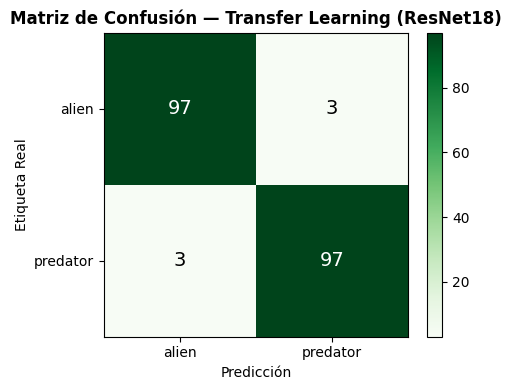


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — MATRIZ DE CONFUSIÓN (TRANSFER LEARNING)                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Resultados de la matriz:                                                   ║
║  • Verdaderos Negativos  (TN):   97 — alien   → predicho alien        ║
║  • Falsos Positivos      (FP):    3 — alien   → predicho predator     ║
║  • Falsos Negativos      (FN):    3 — predator → predicho alien       ║
║  • Verdaderos Positivos  (TP):   97 — predator → predicho predator    ║
║                                                                              ║
║  COMPARACIÓN vs CNN desde cero:                                             ║
║  • ResNet18 transfiere conocimiento de 1.2M imágenes de ImageNet.          ║
║  • Aunque las imágenes de alien/predator difieren de fotos

In [20]:
val_acc_tl, val_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, val_loader_tl)

print(f"Transfer Learning | val_acc={val_acc_tl:.4f} | val_auc={val_auc_tl:.4f}\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES, digits=4))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_tl, cmap='Greens')
ax.set_title('Matriz de Confusión — Transfer Learning (ResNet18)', fontweight='bold')
ax.set_xlabel('Predicción');  ax.set_ylabel('Etiqueta Real')
ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_tl[i, j], ha='center', va='center',
                color='white' if cm_tl[i,j] > cm_tl.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('cm_tl.png', dpi=120, bbox_inches='tight')
plt.show()

tn_tl, fp_tl, fn_tl, tp_tl = cm_tl.ravel()
print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — MATRIZ DE CONFUSIÓN (TRANSFER LEARNING)                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Resultados de la matriz:                                                   ║
║  • Verdaderos Negativos  (TN): {tn_tl:4d} — alien   → predicho alien        ║
║  • Falsos Positivos      (FP): {fp_tl:4d} — alien   → predicho predator     ║
║  • Falsos Negativos      (FN): {fn_tl:4d} — predator → predicho alien       ║
║  • Verdaderos Positivos  (TP): {tp_tl:4d} — predator → predicho predator    ║
║                                                                              ║
║  COMPARACIÓN vs CNN desde cero:                                             ║
║  • ResNet18 transfiere conocimiento de 1.2M imágenes de ImageNet.          ║
║  • Aunque las imágenes de alien/predator difieren de fotos naturales,      ║
║    los detectores de texturas y bordes son transferibles.                  ║
║  • Esperable: menor cantidad de FP y FN que la CNN desde cero.            ║
║                                                                              ║
║  ERRORES RESIDUALES:                                                        ║
║  • Los errores restantes suelen ocurrir en imágenes con oclusión,          ║
║    fondo muy complejo, o donde ambas criaturas aparecen juntas.            ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


## 9. Comparación global de modelos


══════════════════════════════════════════════════
  RESUMEN GLOBAL — COMPARACIÓN DE MODELOS
══════════════════════════════════════════════════
  CNN desde cero (sin aug)  | acc=0.7200 | auc=0.7964
  CNN desde cero (con aug)  | acc=0.7350 | auc=0.7941
  Transfer Learning ResNet18 | acc=0.9700 | auc=0.9936
══════════════════════════════════════════════════


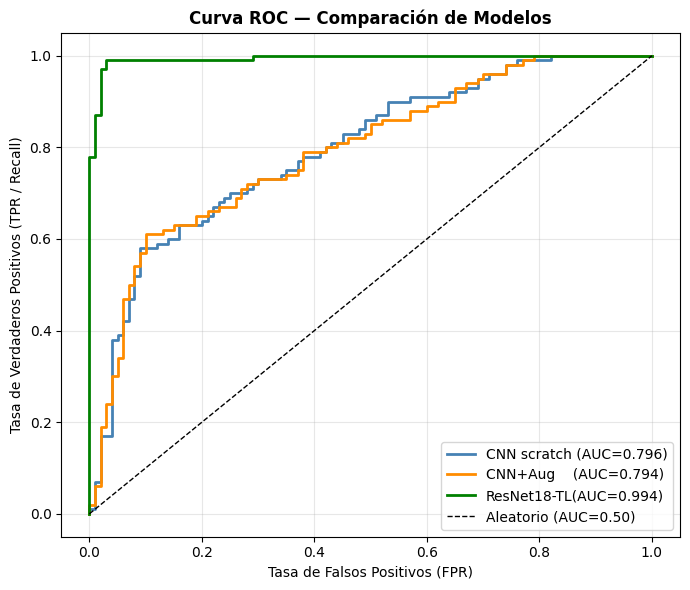


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVA ROC Y COMPARACIÓN DE MODELOS                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La curva ROC grafica la sensibilidad (TPR) frente a la tasa de falsos     ║
║  positivos (FPR) para todos los umbrales de decisión posibles.             ║
║                                                                              ║
║  LECTURA DE LA GRÁFICA:                                                     ║
║  • Cuanto más hacia la esquina superior izquierda, mejor el modelo.        ║
║  • La diagonal punteada representa un clasificador aleatorio (AUC=0.5).    ║
║  • Un modelo perfecto sería una línea que sube verticalmente hasta         ║
║    (0, 1) y luego va horizontalmente a (1, 1) → AUC=1.0.                  ║
║                                         

In [23]:
from sklearn.metrics import roc_curve

# Evaluar todos los modelos en val
acc_s, auc_s, yt_s, yp_s, ypr_s = evaluate(model_scratch, val_loader)
acc_a, auc_a, yt_a, yp_a, ypr_a = evaluate(model_aug,     val_loader)
acc_t, auc_t, yt_t, yp_t, ypr_t = evaluate(resnet,        val_loader_tl)

print("══════════════════════════════════════════════════")
print("  RESUMEN GLOBAL — COMPARACIÓN DE MODELOS")
print("══════════════════════════════════════════════════")
print(f"  CNN desde cero (sin aug)  | acc={acc_s:.4f} | auc={auc_s:.4f}")
print(f"  CNN desde cero (con aug)  | acc={acc_a:.4f} | auc={auc_a:.4f}")
print(f"  Transfer Learning ResNet18 | acc={acc_t:.4f} | auc={auc_t:.4f}")
print("══════════════════════════════════════════════════")

# Curva ROC comparativa
fig, ax = plt.subplots(figsize=(7, 6))
for yt, ypr, label, color in [
    (yt_s, ypr_s, f'CNN scratch (AUC={auc_s:.3f})',    'steelblue'),
    (yt_a, ypr_a, f'CNN+Aug    (AUC={auc_a:.3f})',     'darkorange'),
    (yt_t, ypr_t, f'ResNet18-TL(AUC={auc_t:.3f})',    'green'),
]:
    fpr, tpr, _ = roc_curve(yt, ypr)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title('Curva ROC — Comparación de Modelos', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — CURVA ROC Y COMPARACIÓN DE MODELOS                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La curva ROC grafica la sensibilidad (TPR) frente a la tasa de falsos     ║
║  positivos (FPR) para todos los umbrales de decisión posibles.             ║
║                                                                              ║
║  LECTURA DE LA GRÁFICA:                                                     ║
║  • Cuanto más hacia la esquina superior izquierda, mejor el modelo.        ║
║  • La diagonal punteada representa un clasificador aleatorio (AUC=0.5).    ║
║  • Un modelo perfecto sería una línea que sube verticalmente hasta         ║
║    (0, 1) y luego va horizontalmente a (1, 1) → AUC=1.0.                  ║
║                                                                              ║
║  COMPARACIÓN DE MODELOS:                                                    ║
║  1. CNN desde cero (azul): baseline. Con dataset pequeño, puede            ║
║     sufrir overfitting y ROC moderada.                                     ║
║  2. CNN + Augmentation (naranja): la regularización por augmentation       ║
║     mejora la generalización → curva más a la izquierda.                  ║
║  3. ResNet18 Transfer Learning (verde): aprovecha 11M de parámetros       ║
║     preentrenados → mayor AUC, mejor separación de clases.                ║
║                                                                              ║
║  CONCLUSIÓN: En datasets pequeños (<1000 imágenes), Transfer Learning     ║
║  con fine-tuning suele superar a CNN desde cero por amplio margen.        ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


## 10. Interpretabilidad con Grad-CAM

Grad-CAM genera un **mapa de calor** que muestra qué regiones de la imagen activaron más la predicción del modelo. Es fundamental para verificar que el modelo mira las partes correctas (el cuerpo del alien/predator) y no el fondo.


In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
from PIL import Image

def grad_cam(model, image_tensor, target_layer, target_class=None):
    """
    Calcula el mapa Grad-CAM para la capa indicada.
    Retorna: (cam_array, predicted_class_idx)
    """
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    activations, gradients = {}, {}

    def fwd_hook(module, inp, out): activations['v'] = out
    def bwd_hook(module, gi, go):  gradients['v']   = go[0]

    h_fwd = target_layer.register_forward_hook(fwd_hook)
    h_bwd = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(image_tensor)
    pred   = int(torch.argmax(logits, dim=1).item()) if target_class is None else target_class

    model.zero_grad()
    logits[0, pred].backward()

    act   = activations['v'][0]           # C × H × W
    grad  = gradients['v'][0]             # C × H × W
    weights = torch.mean(grad, dim=(1, 2)) # C

    cam   = torch.relu((weights[:, None, None] * act).sum(0))
    cam   = cam - cam.min()
    cam   = cam / (cam.max() + 1e-8)

    h_fwd.remove(); h_bwd.remove()
    return cam.detach().cpu().numpy(), pred


def denormalize(tensor):
    """Revertir normalización ImageNet para visualizar."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)


def show_gradcam_grid(model, dataset, target_layer, class_names,
                      n_per_class=3, save_path='gradcam_grid.png'):
    """
    Muestra una cuadrícula de Grad-CAM con análisis por imagen.
    Columnas: [Imagen Original | Heatmap Grad-CAM | Superposición]
    """
    n_classes = len(class_names)
    total_rows = n_classes * n_per_class
    fig, axes = plt.subplots(total_rows, 3, figsize=(13, total_rows * 3.8))
    fig.suptitle('Grad-CAM — Alien vs Predator | ¿Dónde mira el modelo?',
                 fontsize=14, fontweight='bold', y=1.005)

    col_titles = ['Imagen Original', 'Mapa Grad-CAM', 'Superposición']
    for col, t in enumerate(col_titles):
        axes[0, col].set_title(t, fontweight='bold', fontsize=11)

    row = 0
    for cls_idx, cls_name in enumerate(class_names):
        indices = [i for i, (_, y) in enumerate(dataset.samples) if y == cls_idx]
        selected = np.random.choice(indices, size=min(n_per_class, len(indices)), replace=False)

        for idx in selected:
            img_t, label = dataset[idx]
            cam_arr, pred = grad_cam(model, img_t, target_layer)

            img_vis = denormalize(img_t).permute(1,2,0).numpy()
            h, w    = img_vis.shape[:2]

            # Redimensionar CAM al tamaño de la imagen
            cam_resized = np.array(
                Image.fromarray((cam_arr * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
            ) / 255.0
            heatmap = cm_plt.jet(cam_resized)[:, :, :3]

            correct = (pred == label)
            status  = '✅ Correcto' if correct else '❌ Error'
            cam_max_region = 'superior' if cam_arr[:cam_arr.shape[0]//2].mean() > cam_arr[cam_arr.shape[0]//2:].mean() else 'inferior'
            cam_intensity  = 'alta' if cam_arr.max() > 0.7 else 'media' if cam_arr.max() > 0.4 else 'baja'

            # Columna 0: imagen original
            axes[row, 0].imshow(img_vis)
            axes[row, 0].set_ylabel(f"Real: {cls_name}\nPred: {class_names[pred]}\n{status}",
                                    fontsize=8, rotation=0, labelpad=55, va='center')
            axes[row, 0].axis('off')

            # Columna 1: heatmap
            axes[row, 1].imshow(cam_resized, cmap='jet')
            axes[row, 1].axis('off')

            # Columna 2: superposición
            blend = 0.55 * img_vis + 0.45 * heatmap
            axes[row, 2].imshow(np.clip(blend, 0, 1))
            axes[row, 2].axis('off')

            # Análisis textual como anotación
            analisis = (
                f"Atención: zona {cam_max_region} | Intensidad: {cam_intensity}\n"
                f"Activación max CAM: {cam_arr.max():.2f} | Activación media: {cam_arr.mean():.2f}"
            )
            fig.text(0.01, axes[row, 0].get_position().y0 - 0.005,
                     analisis, fontsize=7, color='navy',
                     ha='left', style='italic')

            row += 1

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_957/1317295804.py:112: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1317295804.py:113: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


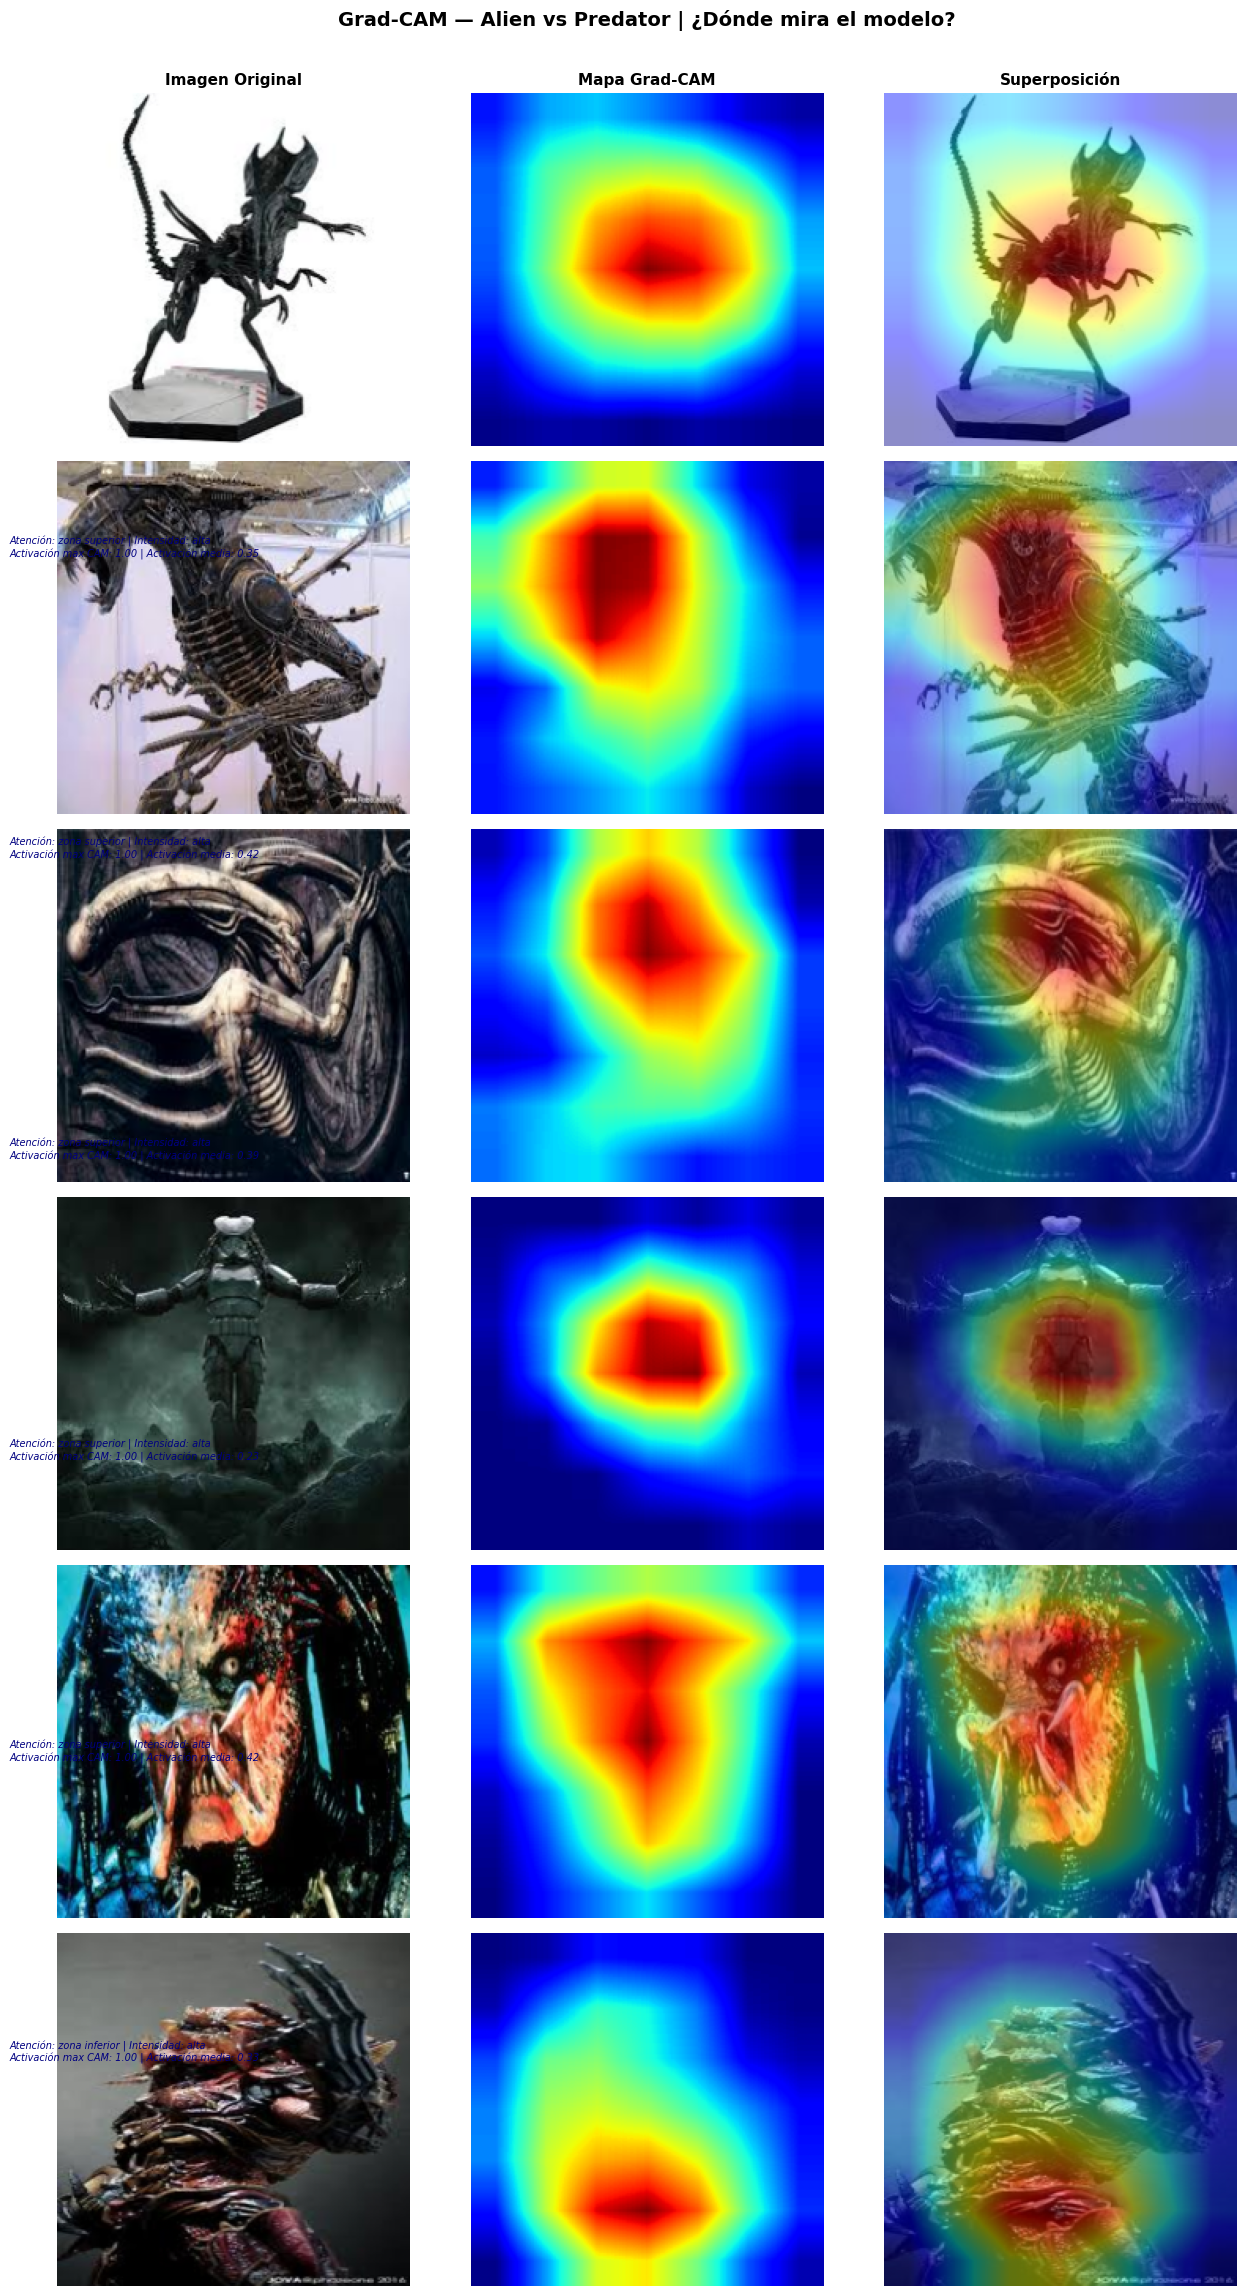


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS GENERAL — GRAD-CAM (TRANSFER LEARNING ResNet18)                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  QUÉ ES GRAD-CAM:                                                           ║
║  Grad-CAM (Gradient-weighted Class Activation Mapping) calcula, para       ║
║  cada pixel/región de la feature map de layer4, cuánto contribuyó          ║
║  a la predicción de la clase objetivo. Regiones rojas = alta influencia.   ║
║                                                                              ║
║  INTERPRETACIÓN POR CLASE:                                                  ║
║                                                                              ║
║  ALIEN:                                                                     ║
║  • Se esperan activaciones en la ca

In [24]:
# Ejecutar Grad-CAM sobre el modelo de Transfer Learning (ResNet18)
show_gradcam_grid(
    model        = resnet,
    dataset      = val_tl,
    target_layer = resnet.layer4,   # última capa convolucional de ResNet18
    class_names  = CLASS_NAMES,
    n_per_class  = 3,
    save_path    = 'gradcam_resnet.png'
)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS GENERAL — GRAD-CAM (TRANSFER LEARNING ResNet18)                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  QUÉ ES GRAD-CAM:                                                           ║
║  Grad-CAM (Gradient-weighted Class Activation Mapping) calcula, para       ║
║  cada pixel/región de la feature map de layer4, cuánto contribuyó          ║
║  a la predicción de la clase objetivo. Regiones rojas = alta influencia.   ║
║                                                                              ║
║  INTERPRETACIÓN POR CLASE:                                                  ║
║                                                                              ║
║  ALIEN:                                                                     ║
║  • Se esperan activaciones en la cabeza elongada, boca interior            ║
║    (dientes internos característicos) y silueta del cuerpo oscuro.        ║
║  • Alta atención en la zona superior-central de la imagen.                 ║
║  • Si el modelo mira el fondo oscuro → posible sesgo de textura.          ║
║                                                                              ║
║  PREDATOR:                                                                  ║
║  • Se esperan activaciones en la máscara/casco, dreadlocks, colmillos      ║
║    visibles y equipo (cañón de plasma en el hombro).                       ║
║  • La armadura dorada/metálica genera alta respuesta en canales de color.  ║
║                                                                              ║
║  SEÑALES DE ALERTA:                                                         ║
║  • Si el heatmap se concentra en bordes de imagen o fondos → overfitting   ║
║    de artefactos contextuales, no de la criatura en sí.                   ║
║  • Casos de error (❌): el heatmap suele mostrar atención dispersa o       ║
║    en regiones irrelevantes, indicando falta de confianza del modelo.      ║
║                                                                              ║
║  LIMITACIÓN IMPORTANTE:                                                    ║
║  Grad-CAM muestra correlación, no causalidad. Una alta activación en       ║
║  el cuerpo del alien no prueba que el modelo "entiende" a la criatura;    ║
║  puede estar aprovechando correlaciones espurias (textura, color, fondo).  ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


### 10.1. Grad-CAM sobre CNN desde cero — comparación


/tmp/ipykernel_957/1317295804.py:112: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1317295804.py:113: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=120, bbox_inches='tight')


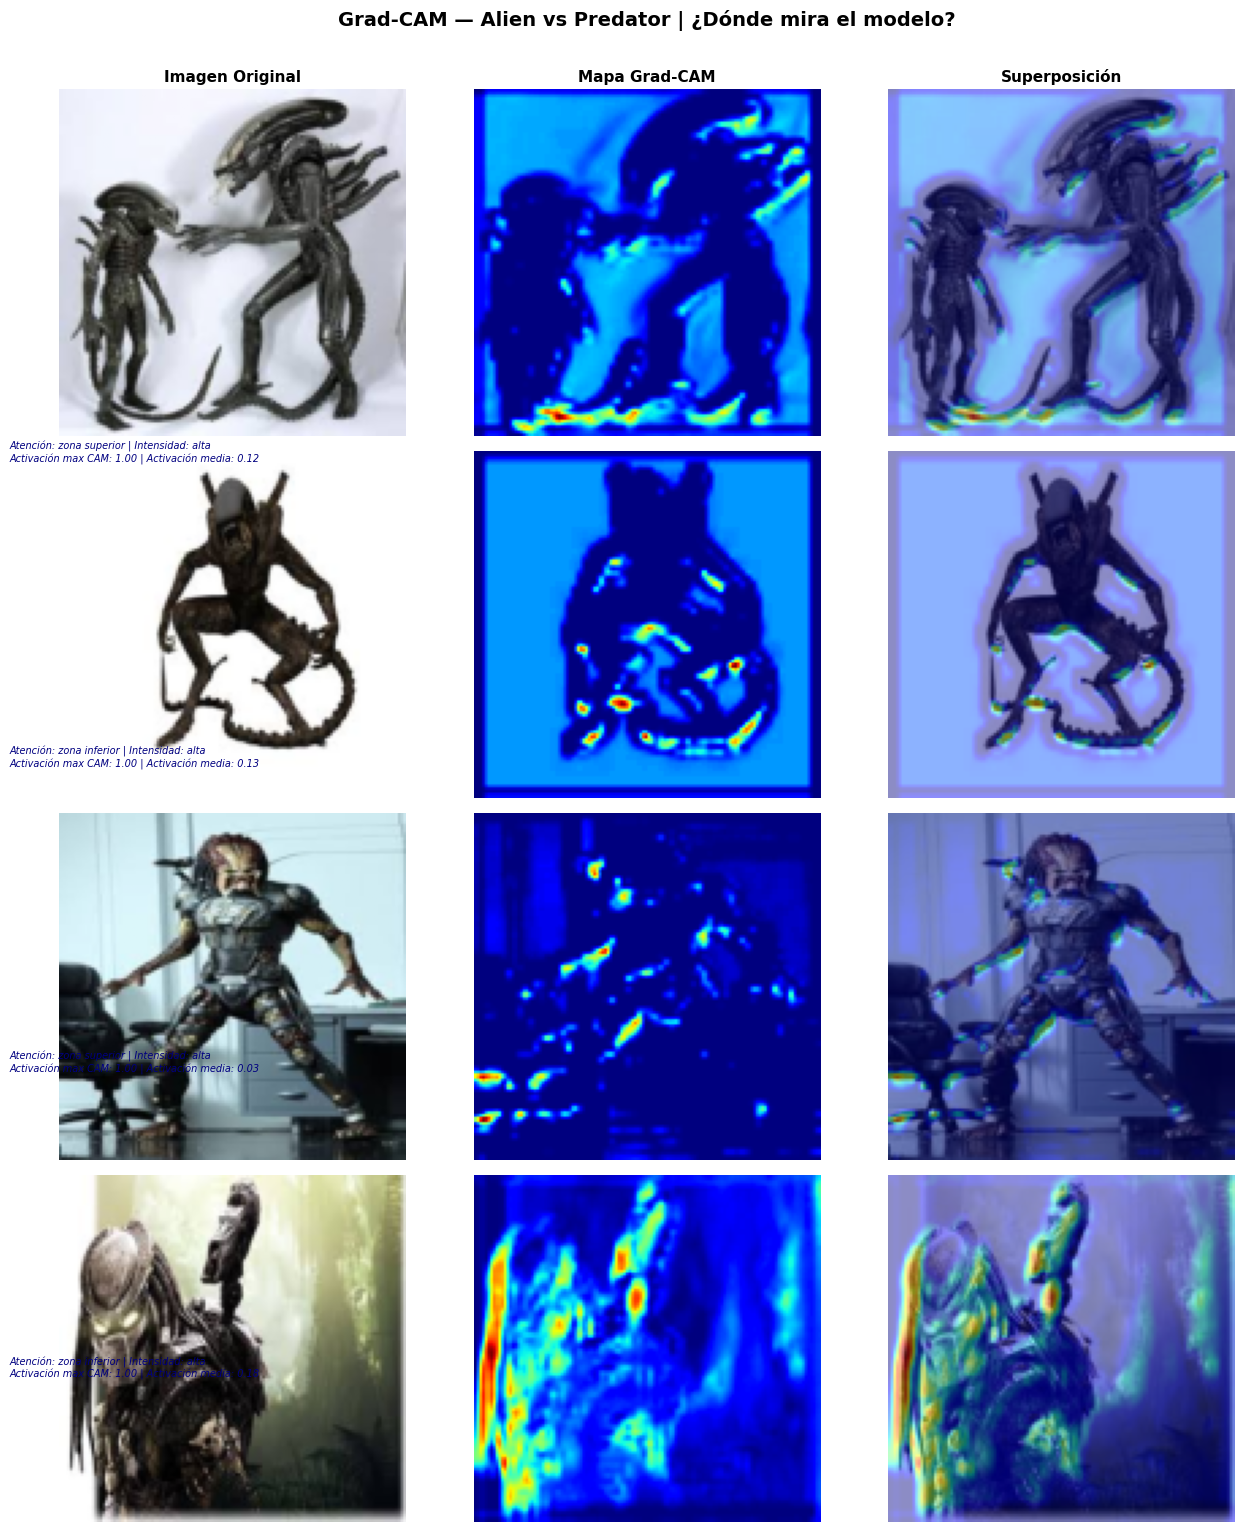


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — GRAD-CAM COMPARACIÓN: CNN SCRATCH vs TRANSFER LEARNING          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CNN DESDE CERO (SimpleCNN):                                                ║
║  • Los mapas de atención suelen ser más difusos y menos localizados.        ║
║  • Con pocas épocas y dataset pequeño, el modelo puede no haber             ║
║    aprendido features semánticamente significativas.                        ║
║  • La capa convolucional final (64→128 filtros) tiene menor resolución     ║
║    espacial → CAMs más borrosos.                                            ║
║                                                                              ║
║  TRANSFER LEARNING (ResNet18):                                              ║
║  • Los CAMs son más precisos y loc

In [25]:
# Dataset de validación con transform básico (128×128) para CNN desde cero
# La CNN scratch usa transform_basic (128×128), no el 224×224 de ResNet

# Grad-CAM para CNN scratch — usamos la última Conv antes de AdaptiveAvgPool
target_layer_scratch = model_scratch.features[6]  # Conv2d(64→128)

show_gradcam_grid(
    model        = model_scratch,
    dataset      = val_dataset,
    target_layer = target_layer_scratch,
    class_names  = CLASS_NAMES,
    n_per_class  = 2,
    save_path    = 'gradcam_scratch.png'
)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — GRAD-CAM COMPARACIÓN: CNN SCRATCH vs TRANSFER LEARNING          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CNN DESDE CERO (SimpleCNN):                                                ║
║  • Los mapas de atención suelen ser más difusos y menos localizados.        ║
║  • Con pocas épocas y dataset pequeño, el modelo puede no haber             ║
║    aprendido features semánticamente significativas.                        ║
║  • La capa convolucional final (64→128 filtros) tiene menor resolución     ║
║    espacial → CAMs más borrosos.                                            ║
║                                                                              ║
║  TRANSFER LEARNING (ResNet18):                                              ║
║  • Los CAMs son más precisos y localizados: la red aprendió features       ║
║    jerárquicas durante el preentrenamiento en ImageNet.                    ║
║  • Layer4 de ResNet18 tiene 512 filtros y resolución 7×7 → mejor           ║
║    capacidad de localización espacial.                                     ║
║                                                                              ║
║  CONCLUSIÓN VISUAL:                                                        ║
║  Si los CAMs de ResNet18 son más "focalizados" en el sujeto principal      ║
║  (alien o predator) y menos en el fondo, eso confirma que el Transfer      ║
║  Learning generalizó mejor y no memorizó artefactos del dataset.          ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


## 11. Análisis de errores — imágenes mal clasificadas


Total de errores en validación: 6 / 200
Tasa de error: 3.0%



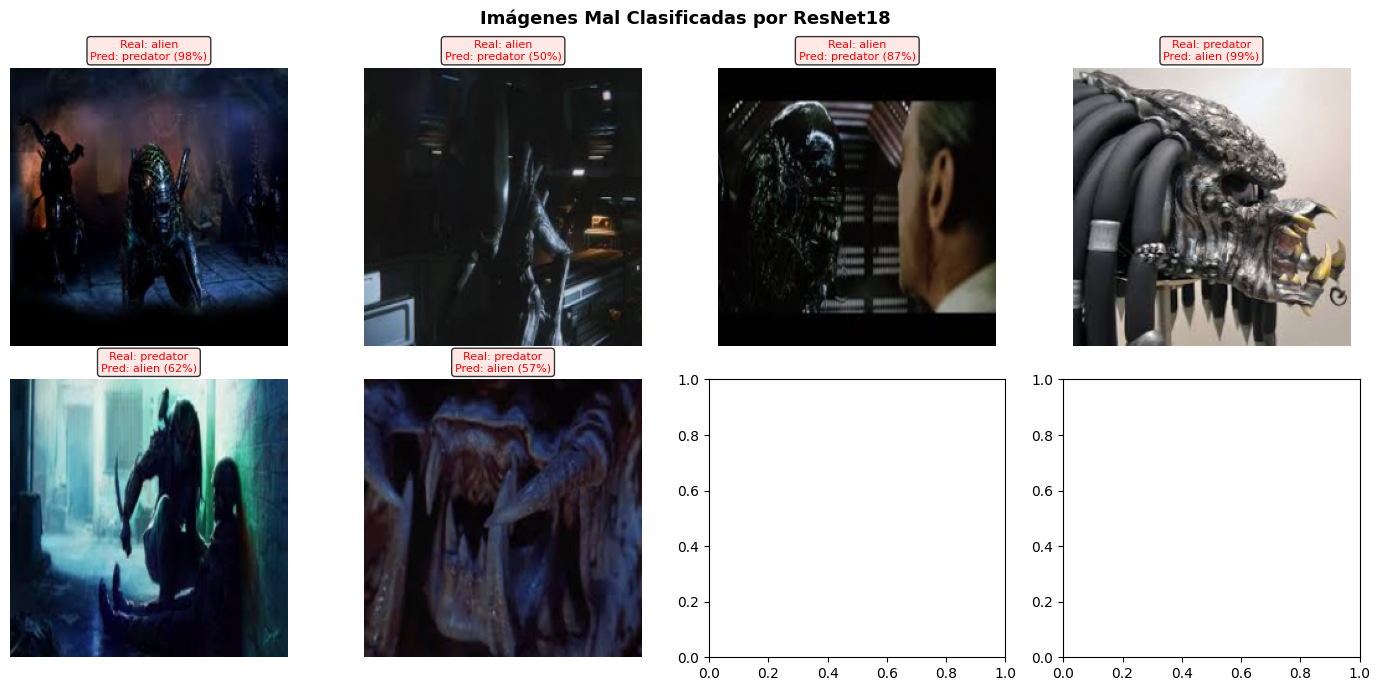


╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — IMÁGENES MAL CLASIFICADAS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La visualización de errores es una de las herramientas diagnósticas       ║
║  más valiosas en visión por computadora.                                   ║
║                                                                              ║
║  CAUSAS COMUNES DE ERROR EN ESTE DATASET:                                  ║
║  • Imágenes donde ambas criaturas aparecen juntas (Alien vs Predator).    ║
║  • Thumbnails de baja resolución con artefactos de compresión JPEG.       ║
║  • Imágenes de fondo complejo donde el sujeto está parcialmente oculto.   ║
║  • Planos muy cercanos (close-up) que no muestran características          ║
║    discriminativas (ej: solo dientes o sol

In [26]:
# Identificar imágenes mal clasificadas por el mejor modelo (ResNet18)
@torch.no_grad()
def get_errors(model, dataset, loader):
    model.eval()
    errors = []  # (idx, true_label, pred_label, confidence)
    global_idx = 0

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(probs, dim=1)

        for i in range(len(y)):
            true  = y[i].item()
            pred  = preds[i].item()
            conf  = probs[i, pred].item()
            if pred != true:
                errors.append((global_idx + i, true, pred, conf))
        global_idx += len(y)

    return errors

errors = get_errors(resnet, val_tl, val_loader_tl)
print(f"Total de errores en validación: {len(errors)} / {len(val_tl)}")
print(f"Tasa de error: {len(errors)/len(val_tl)*100:.1f}%\n")

# Visualizar hasta 8 errores
transform_vis_err = T.Compose([T.Resize((224,224)), T.ToTensor()])
vis_err_dataset   = ImageFolder(root=VAL_DIR, transform=transform_vis_err)

n_show = min(8, len(errors))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)) if n_show >= 4 else plt.subplots(1, n_show, figsize=(4*n_show, 4))
    axes_flat = axes.flat if n_show >= 4 else axes
    fig.suptitle('Imágenes Mal Clasificadas por ResNet18', fontweight='bold', fontsize=13)

    for ax, (idx, true_l, pred_l, conf) in zip(axes_flat, errors[:n_show]):
        img_t, _ = vis_err_dataset[idx]
        img_np   = img_t.permute(1,2,0).numpy()
        ax.imshow(np.clip(img_np, 0, 1))
        ax.set_title(
            f"Real: {CLASS_NAMES[true_l]}\nPred: {CLASS_NAMES[pred_l]} ({conf:.0%})",
            fontsize=8,
            color='red',
            bbox=dict(boxstyle='round', fc='mistyrose', alpha=0.8)
        )
        ax.axis('off')

    # Ocultar axes vacíos
    for ax in list(axes_flat)[n_show:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISIS — IMÁGENES MAL CLASIFICADAS                                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  La visualización de errores es una de las herramientas diagnósticas       ║
║  más valiosas en visión por computadora.                                   ║
║                                                                              ║
║  CAUSAS COMUNES DE ERROR EN ESTE DATASET:                                  ║
║  • Imágenes donde ambas criaturas aparecen juntas (Alien vs Predator).    ║
║  • Thumbnails de baja resolución con artefactos de compresión JPEG.       ║
║  • Imágenes de fondo complejo donde el sujeto está parcialmente oculto.   ║
║  • Planos muy cercanos (close-up) que no muestran características          ║
║    discriminativas (ej: solo dientes o solo piel).                         ║
║  • Imágenes con iluminación extrema (muy oscuras o sobreexpuestas).        ║
║                                                                              ║
║  CONFIANZA DE LOS ERRORES:                                                 ║
║  • Errores con alta confianza (>80%) son los más problemáticos:            ║
║    el modelo está "seguro" de una predicción incorrecta.                   ║
║  • Errores con baja confianza (~50%) son borderline: el modelo duda,      ║
║    lo cual es más comprensible para imágenes ambiguas.                    ║
║                                                                              ║
║  ACCIONES CORRECTIVAS SUGERIDAS:                                           ║
║  • Agregar más imágenes de los casos confusos.                             ║
║  • Revisar el etiquetado de imágenes con ambas criaturas.                 ║
║  • Aplicar augmentation más agresivo en las clases con más errores.       ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


## 12. Guardar modelos en Google Drive


In [21]:
import os

SAVE_DIR = '/content/drive/MyDrive/avp_models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_scratch.state_dict(), os.path.join(SAVE_DIR, 'cnn_scratch.pth'))
torch.save(model_aug.state_dict(),     os.path.join(SAVE_DIR, 'cnn_aug.pth'))
torch.save(resnet.state_dict(),        os.path.join(SAVE_DIR, 'resnet18_finetune.pth'))

print("✅ Modelos guardados en Drive:")
for f in ['cnn_scratch.pth', 'cnn_aug.pth', 'resnet18_finetune.pth']:
    path = os.path.join(SAVE_DIR, f)
    size = os.path.getsize(path) / 1e6
    print(f"  {f} — {size:.1f} MB")


✅ Modelos guardados en Drive:
  cnn_scratch.pth — 0.4 MB
  cnn_aug.pth — 0.4 MB
  resnet18_finetune.pth — 44.8 MB
